In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def norm_pdf(x):
    """Плотность нормального распределения N(0,1)"""
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def cauchy_pdf(x):
    """Плотность распределения Коши C(0,1)"""
    return 1 / (np.pi * (1 + x**2))

def laplace_pdf(x, b=1/np.sqrt(2)):
    """Плотность распределения Лапласа L(0, b) с b = 1/√2"""
    return (1 / (2 * b)) * np.exp(-np.abs(x) / b)

def uniform_pdf(x, a=-np.sqrt(3), b=np.sqrt(3)):
    """Плотность равномерного распределения U(a,b)"""
    if isinstance(x, np.ndarray):
        pdf = np.zeros_like(x)
        mask = (x >= a) & (x <= b)
        pdf[mask] = 1 / (b - a)
        return pdf
    else:
        return 1/(b-a) if a <= x <= b else 0.0

def poisson_pmf(k, lam=10):
    """Теоретические вероятности Пуассона P(k;10)"""
    from math import factorial, exp
    return exp(-lam) * (lam**k) / factorial(k)


In [3]:
n_values = [10, 100, 1000]
distributions = {
    "Normal (μ=0, σ=1)": {
        "generator": lambda n: np.random.normal(0, 1, n),
        "pdf": norm_pdf,
        "x_range": (-4, 4)
    },
    "Cauchy (x0=0, γ=1)": {
        "generator": lambda n: np.random.standard_cauchy(n),
        "pdf": cauchy_pdf,
        "x_range": (-6, 6)
    },
    "Laplace (μ=0, b=1/√2)": {
        "generator": lambda n: np.random.laplace(0, 1/np.sqrt(2), n),
        "pdf": laplace_pdf,
        "x_range": (-5, 5)
    },
    "Poisson (λ=10)": {
        "generator": lambda n: np.random.poisson(10, n),
        "pdf": None,   # отдельная обработка
        "x_range": (0, 20)
    },
    "Uniform (a=-√3, b=√3)": {
        "generator": lambda n: np.random.uniform(-np.sqrt(3), np.sqrt(3), n),
        "pdf": uniform_pdf,
        "x_range": (-2.5, 2.5)
    }
}


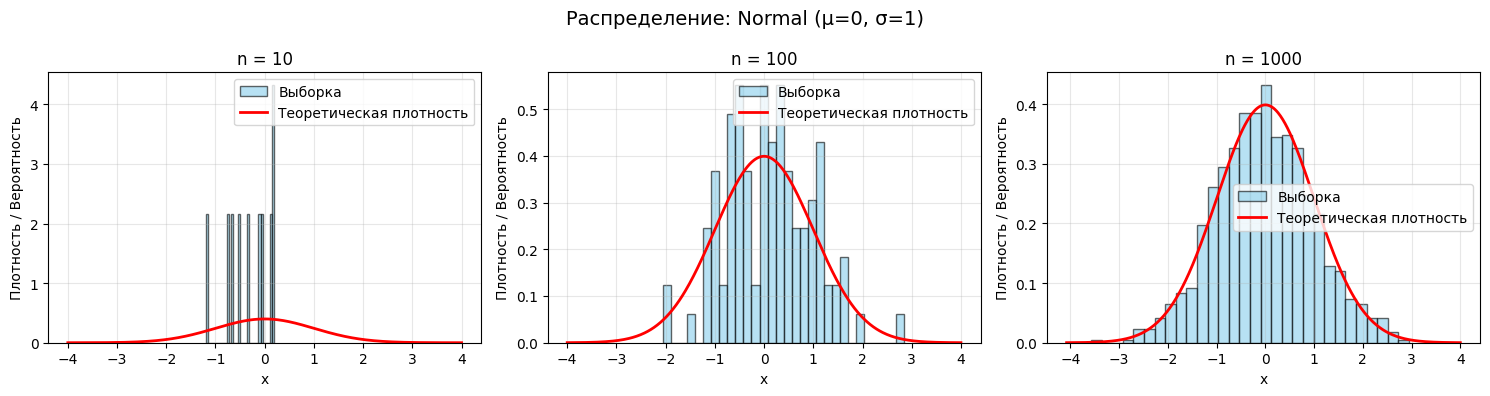

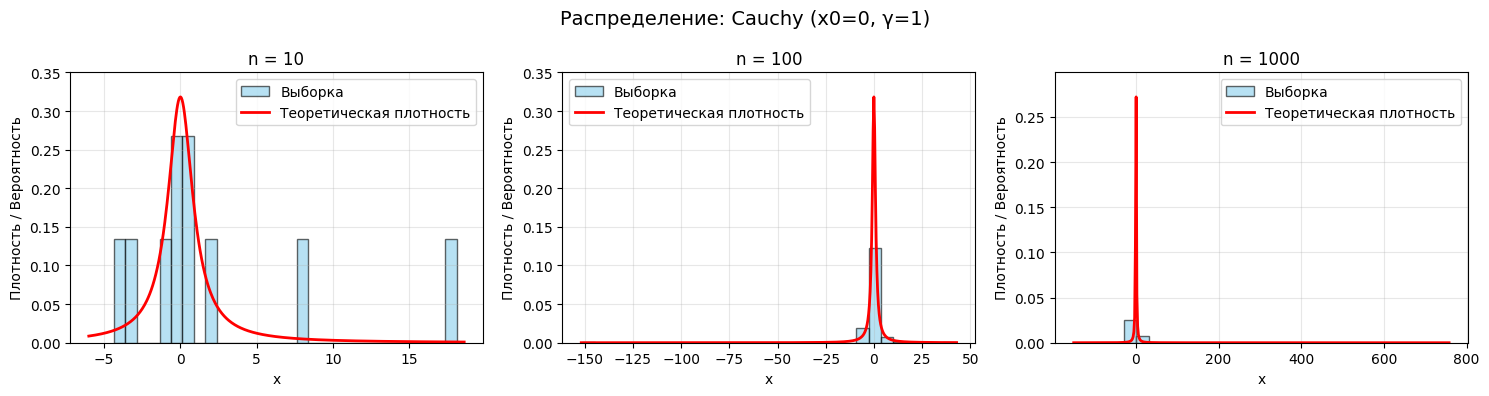

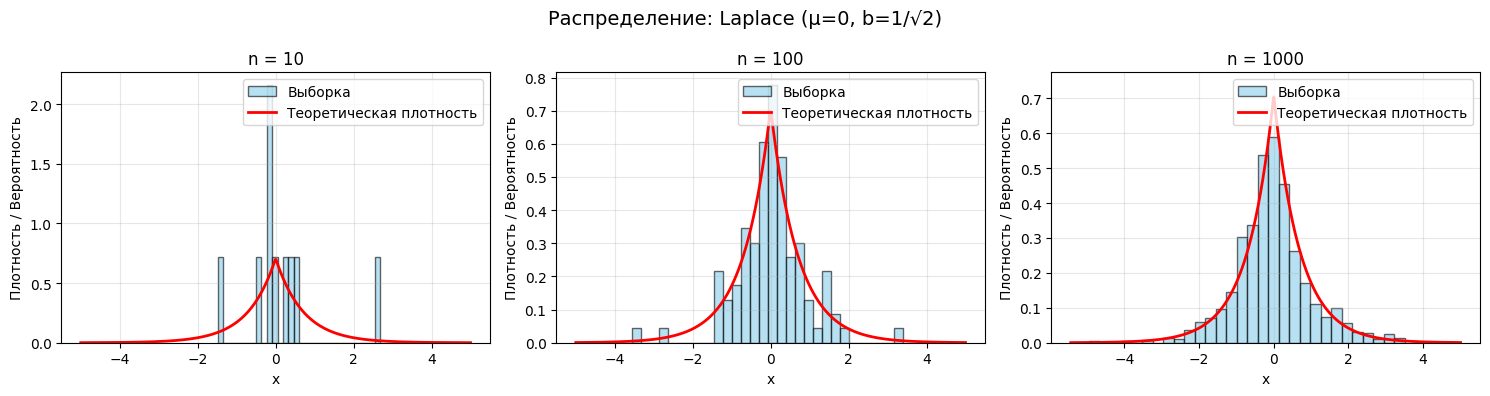

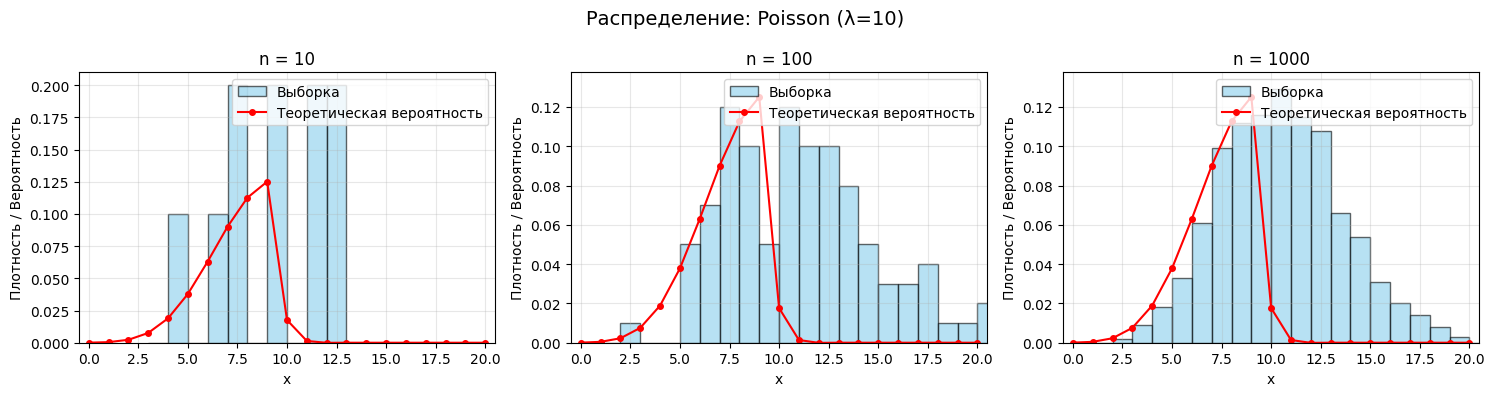

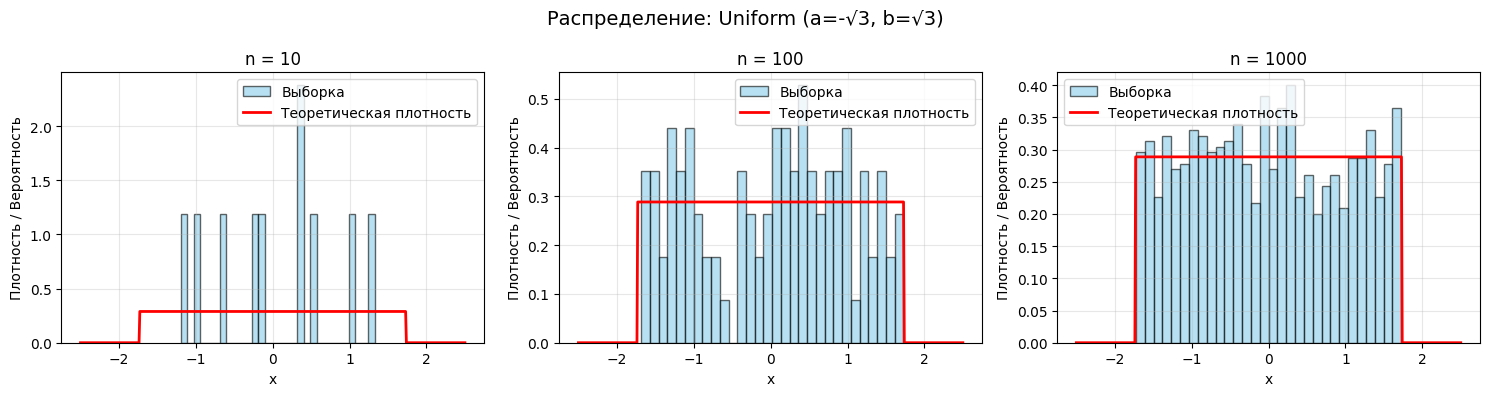

In [4]:
for dist_name, params in distributions.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Распределение: {dist_name}", fontsize=14)

    for idx, n in enumerate(n_values):
        ax = axes[idx]
        # Генерация выборки
        sample = params["generator"](n)

        if dist_name == "Poisson (λ=10)":
            # ----- Дискретное распределение Пуассона -----
            # Вычисляем теоретические вероятности для k от 0 до 20
            k_vals = np.arange(0, 21)
            theo_probs = np.array([poisson_pmf(k) for k in k_vals])

            # Определяем границы для гистограммы (ширина бина = 1)
            min_val = max(0, sample.min() - 0.5)
            max_val = sample.max() + 0.5
            bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

            # Строим нормированную гистограмму (площадь = 1)
            ax.hist(sample, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Выборка')

            # Нормируем теоретические вероятности (для плотности: так как ширина бина = 1, высота = вероятность)
            ax.plot(k_vals, theo_probs, 'ro-', markersize=4, label='Теоретическая вероятность')
            ax.set_xlim(-0.5, 20.5)
            ax.set_ylim(0, max(ax.get_ylim()[1], max(theo_probs)*1.1))

        else:
            # ----- Непрерывные распределения -----
            # Определяем диапазон x для отображения теоретической кривой
            x_min, x_max = params["x_range"]
            # Но для малых n выборка может выходить за пределы, расширим границы
            x_min_dyn = min(x_min, sample.min() - 0.5)
            x_max_dyn = max(x_max, sample.max() + 0.5)
            x_grid = np.linspace(x_min_dyn, x_max_dyn, 500)

            # Теоретическая плотность
            pdf_vals = params["pdf"](x_grid)

            # Гистограмма выборки (нормированная)
            ax.hist(sample, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Выборка')

            # Теоретическая кривая
            ax.plot(x_grid, pdf_vals, 'r-', linewidth=2, label='Теоретическая плотность')

            # Устанавливаем разумные границы по оси Y
            y_max = max(ax.get_ylim()[1], max(pdf_vals)*1.1)
            ax.set_ylim(0, y_max)

        # Оформление подграфика
        ax.set_title(f'n = {n}')
        ax.set_xlabel('x')
        ax.set_ylabel('Плотность / Вероятность')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()